# Comparison of reskilling simulation runs
Felix Zaussinger | 21.11.2022

**Core Analysis Goal(s)**
1. Gather the data of all baseline simulations (1), with/ (2) without regional constraints to (a) optimally targeted reskilling and (b) random reskilling scenario.
2. Run this comparison for the three different viability thresholds (low, mid, high).
3. Compare the distributions and run tests on significant differences.

**Key Insight(s)**
1.
2.
3.

In [12]:
import copy
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm
import pickle
from scipy import stats

from src.modelling.reskilling import ReskillingPathways
rp = ReskillingPathways()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read data

##### Define model setting combinations

In [13]:
year = 2019
job_pools = ["brown_techchange"]  # ["coal", "brown_techchange", "brown"]
threshold = "viable-isco4d"  # ["viable-low", "low", "perc", "emp"]
regional_constraints = ["regC", "no-regC"]
reskilling_modes = [
    #"baseline",
    "reskill-random",
    "reskill-coreWeight",
    #"reskill-digital",
    # "coreness_percentile",
    "reskill-optimal",
]

coeff_pool_mapping = {
    "FFPOTC": "COEFF_share_brown_slt"
}

scenario_mapping = {"job_pool": {"coal": "CPO", "brown_techchange": "FFPOTC", "brown": "FFPO"}}

# select True if model results should be updated
overwrite_model_results = True

##### Preprocessing of model outputs

In [14]:
# -----------------------------------------------------------------------
# Collect raw model output across all options (reg/no-reg) and scenarios
# -----------------------------------------------------------------------

# names and paths
folder_name = "reskilling_final_thresh-{threshold}"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_{year}"
output_dir = os.path.join(useful_paths.data_processed, "eulfs", "reskilling_model_results")
fname = "model_data_tidy_{}_{}".format(year, threshold)

if overwrite_model_results:
    # iterate across all options
    data_store = {}

    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            fpath = os.path.join(
                useful_paths.figure_dir,
                #"test",  # todo: delete after testing
                folder_name.format(threshold=threshold),
                fmt_string.format(
                    reskilling_mode=reskilling_mode,
                    regional_constraint=regional_constraint,
                    year=year
                ),
                "{}.pkl".format(
                    fmt_string.format(
                        reskilling_mode=reskilling_mode,
                        regional_constraint=regional_constraint,
                        year=year
                    )
                ),
            )
            data_store[
                (threshold, reskilling_mode, regional_constraint)
            ] = pd.read_pickle(fpath)

    # save to pickle
    fdir_out = os.path.join(
        useful_paths.figure_dir,
        #"test",
        folder_name.format(threshold=threshold),
        "model_data_store.pkl"
    )

    with open(fdir_out, "wb") as handle:
        pickle.dump(data_store, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # -----------------------------------------------------------------------
    # Build up aggregated data cube of modelling results across all scenarios
    # -----------------------------------------------------------------------
    data_tidy = []
    for model_version in tqdm(list(data_store.keys())):
        # threshold - reskilling - regional constraint
        sub_dict = data_store[model_version]

        for job_pool in job_pools:
            # pool - country - DATA
            df_pool = pd.concat(list(sub_dict[job_pool].values()))

            # only keep select variables
            df_pool_sel = df_pool

            # add metadata of model run
            df_pool_sel["job_pool"] = job_pool
            df_pool_sel["viability_threshold"] = model_version[0]
            df_pool_sel["reskilling_mode"] = model_version[1]
            df_pool_sel["regional_constraint"] = model_version[2]

            # append
            data_tidy.append(df_pool_sel)

    df_tidy = pd.concat(data_tidy)
    df_tidy = df_tidy.reset_index()

    # -----------------------------------------------------------------------
    # Clean data set
    # -----------------------------------------------------------------------
    # rename job pools
    df_tidy = df_tidy.replace(scenario_mapping)

    # make sure entries for countries with missing earnings data_transitions are coded as NaNs
    earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE", "GR", "IS", "UK"]
    df_tidy.loc[
        df_tidy["COUNTRYW"].isin(earnings_data_missing),
        "earnings_delta_closest_switch_sum_mio",
    ] = np.nan

    # add nace labels
    df_tidy = pd.merge(df_tidy, rp.nace_labels, on="NACE1D", how="left")

    # Save concatenated results data
    utils.save_df_to_files(
        df=df_tidy,
        output_dir=output_dir,
        fname_no_ext=fname
    )
else:
    # read results from existing model run
    df_tidy = pd.read_pickle(os.path.join(output_dir, fname + ".pkl"))

  0%|          | 0/6 [00:00<?, ?it/s]C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_9044\1566653530.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pool_sel["job_pool"] = job_pool
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_9044\1566653530.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pool_sel["viability_threshold"] = model_version[0]
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_9044\1566653530.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

##### Reduce data set to core sectors for paper

In [15]:
df_tidy = df_tidy.loc[df_tidy["paper_selection"]]

##### Wide to long, Normalisation of earnings data

In [16]:
# define columns to be melted
transitions_cols = df_tidy.columns[df_tidy.columns.str.startswith("n_viable_transitions")].values
viability_cols = df_tidy.columns[df_tidy.columns.str.startswith("n_viable_transitions")].values

earnings_cols = df_tidy.columns[df_tidy.columns.str.startswith("earnings_delta_closest_switch_sum_step")].values
earnings_cols_rel = df_tidy.columns[df_tidy.columns.str.startswith("earnings_delta_closest_switch_step")].values

index_cols = set(df_tidy.columns) - set(transitions_cols) - set(earnings_cols)

# normalise earnings to worker level
# todo: could also just use all cols matching 'earnings_delta_closest_switch_step'
df_tidy_norm = df_tidy.copy(deep=True)
for earnings_col in earnings_cols:
    df_tidy_norm[earnings_col] = df_tidy_norm[earnings_col] / df_tidy_norm[coeff_pool_mapping[scenario_mapping["job_pool"][job_pool]]]

# melt to long format
df_tidy_long_transitions = df_tidy.melt(id_vars=index_cols, value_vars=transitions_cols, var_name="reskilling_step", value_name="n_transitions")
df_tidy_long_transitions["reskilling_step"] = df_tidy_long_transitions["reskilling_step"].str.split("_").str[-1].astype(int)

# absolute earnings losses (not per-worker numbers)
df_tidy_long_earnings_abs = df_tidy.melt(id_vars=index_cols, value_vars=earnings_cols, var_name="reskilling_step", value_name="earnings_delta_abs")
df_tidy_long_earnings_abs["reskilling_step"] = df_tidy_long_earnings_abs["reskilling_step"].str.split("_").str[-1].astype(int)

# relative earnings losses (per-worker numbers)
df_tidy_long_earnings_rel = df_tidy_norm.melt(id_vars=index_cols, value_vars=earnings_cols, var_name="reskilling_step", value_name="earnings_delta_rel")
df_tidy_long_earnings_rel["reskilling_step"] = df_tidy_long_earnings_rel["reskilling_step"].str.split("_").str[-1].astype(int)

# other earnings figures
df_tidy_long_earnings_abs["earnings_delta_abs_mio"] = df_tidy_long_earnings_abs["earnings_delta_abs"] / 10 ** 6
df_tidy_long_earnings_abs["earnings_delta_abs_bio"] = df_tidy_long_earnings_abs["earnings_delta_abs"] / 10 ** 9

df_tidy_long_earnings_rel["earnings_delta_rel_mio"] = df_tidy_long_earnings_rel["earnings_delta_rel"] / 10 ** 6
df_tidy_long_earnings_rel["earnings_delta_rel_bio"] = df_tidy_long_earnings_rel["earnings_delta_rel"] / 10 ** 9

# # normalise earnings to per worker numbers
# df_tidy_long_earnings_abs["earnings_delta_per_worker"] = df_tidy_long_earnings_abs["earnings_delta"] / df_tidy_long_earnings_abs["COEFF_share_brown_slt"]
# df_tidy_long_earnings_abs["earnings_delta_per_worker_mio"] = df_tidy_long_earnings_abs["earnings_delta_per_worker"] / 10**6
# df_tidy_long_earnings_abs["earnings_delta_per_worker_bio"] = df_tidy_long_earnings_abs["earnings_delta_per_worker"] / 10**9

In [17]:
df_tidy_long_earnings_rel.shape[0] * 2

443784

In [18]:
earnings_abs = df_tidy_long_earnings_abs[["NACE1D_label", "NACE1D_label_short", "COUNTRYW", "NUTS_ID", "regional_constraint", "job_pool", "reskilling_mode", "reskilling_step", "earnings_delta_abs", "earnings_delta_abs_mio", "earnings_delta_abs_bio"]]

earnings_rel = df_tidy_long_earnings_rel[["NACE1D_label", "NACE1D_label_short", "COUNTRYW", "NUTS_ID", "regional_constraint", "job_pool", "reskilling_mode", "reskilling_step", "earnings_delta_rel", "earnings_delta_rel_mio", "earnings_delta_rel_bio"]]

# todo: why is the merge blowing up the n of rows so much, and what duplicates am i dropping?
df_tidy_long_earnings_merged = pd.merge(
    earnings_abs, earnings_rel, on=["COUNTRYW", "NUTS_ID", "NACE1D_label", "reskilling_step"], how="left", suffixes=("", "_drop")
).drop_duplicates()

In [19]:
cols2drop = df_tidy_long_earnings_merged.columns.str.contains("_drop")
df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.loc[:, ~cols2drop]

## Visualisation

##### Plotting parameters

In [20]:
from statannotations.Annotator import Annotator

pairs = []
reskilling_steps = np.arange(0, df_tidy_long_transitions["reskilling_step"].max())
for step in reskilling_steps:
    pair = ((step, "reskill-random"), (step, "reskill-optimal"))
    pairs.append(pair)

alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "outside"
show_test_name = False
verbose = False

# shared across plot versions
job_pool = "FFPOTC"
hue_order = ["reskill-optimal", "reskill-random"]
order = reskilling_steps
palette = "BrBG_r"
figsize=(6, 4)

# errorbar
seed = 42
# errorbar = ("ci", 95)
errorbar = ("sd")
estimator = np.mean

# labelling
ylabel_transitions = "Viable job transitions"
ylabel_earnings = "$\Delta$ Annual Income"
xlabel = "Reskilling journey step"

# annotate units to top of y-axis
yax_title_transitions = "#"
yax_title_earnings = "€"
yax_title_earnings_mio = "€mn"
yax_title_earnings_bio = "€bn"
yax_title_scaling_transitions = 1.01
yax_title_scaling_earnings = 1.05

# output dir
results_dir = os.path.join(
    useful_paths.figure_dir,
    folder_name.format(threshold=threshold)
)

##### Errorbar custom function

In [21]:
def iqr_errorbar(arr):
    iqr = stats.iqr(arr)
    median = np.median(arr)
    return median - iqr, median + iqr

##### Subset job pool and reskilling mode
- avoids double counting (!)

In [22]:
data_transitions = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["job_pool"] == job_pool) & (df_tidy_long_transitions["reskilling_mode"].isin(hue_order))
]

data_earnings = df_tidy_long_earnings_abs.loc[
    (df_tidy_long_earnings_abs["job_pool"] == job_pool) & (df_tidy_long_earnings_abs["reskilling_mode"].isin(hue_order))
    ]

#### Reskilling journey visualisations

##### Fig 5a: Transition numbers across reskilling journey, Main

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


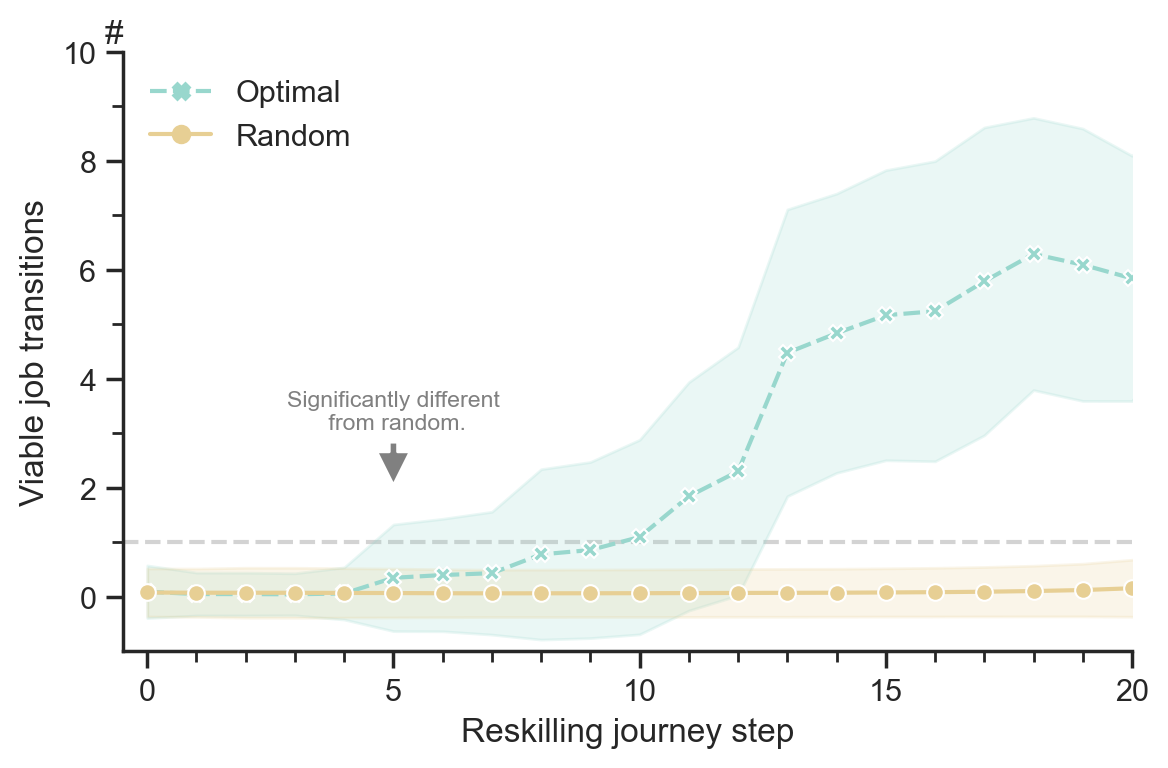

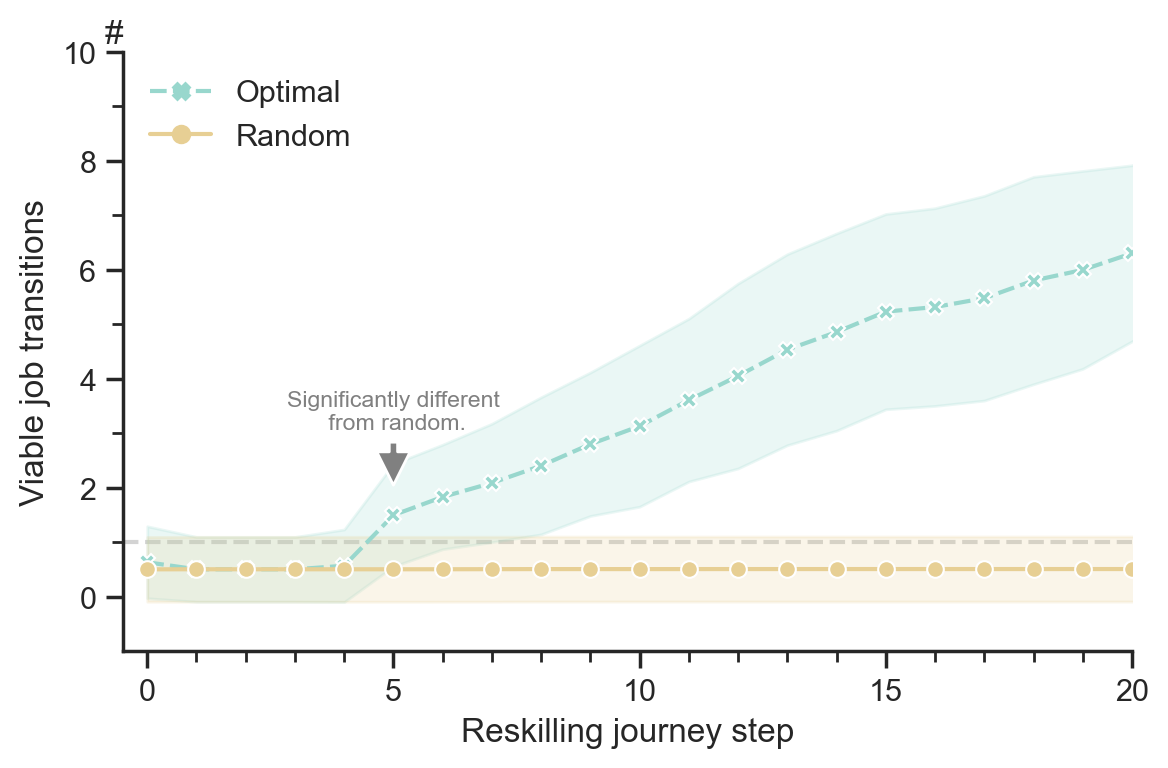

In [23]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "reskilling_mode"  # "NACE1D"
size = None

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    figsize=(6, 4)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_transitions.loc[data_transitions["regional_constraint"] == reg_constraint],
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
        seed=seed,
        ax=ax,
        legend="brief",
    )

    # axes limits and ticks
    xmin = -0.5
    xmax = 20
    ymin = -1
    ymax = 10

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotation
    x_sign, y_sign = 5, 2
    text = "Significantly different\n from random.".format(x_sign)
    ax.annotate(
        text, xy=(x_sign, y_sign),
        xytext=(x_sign, y_sign+1),
        fontsize="x-small",
        arrowprops=dict(facecolor='grey', shrink=0.05, width=3), color="grey",
        horizontalalignment='center', verticalalignment='bottom',
    )

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    legend_locs = [0, 1, 2]
    handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    labels_new = ['Optimal', 'Random', None, None, None, None]
    ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs, data=data_transitions, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=True,
    )
    # annotator.apply_and_annotate()

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()
    plt.tight_layout()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Regional Constraints

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_9044\3090933292.py:58: UserWarning: Legend does not support None instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")


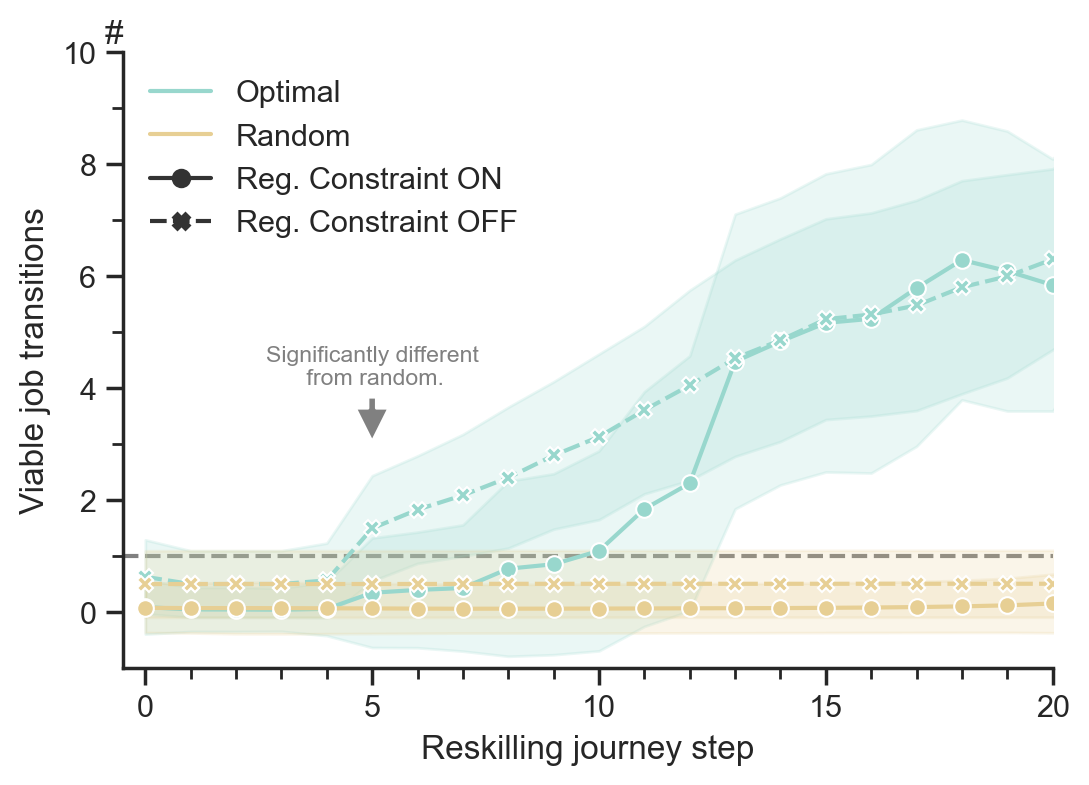

In [24]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "regional_constraint"  # "NACE1D"
size = None

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=errorbar,
    palette=palette,
    seed=seed,
    ax=ax,
    legend="brief"
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

x_sign, y_sign = 5, 3
text = "Significantly different\n from random.".format(x_sign)
ax.annotate(
    text, xy=(x_sign, y_sign),
    xytext=(x_sign, y_sign+1),
    fontsize="x-small",
    arrowprops=dict(facecolor='grey', shrink=0.05, width=3), color="grey",
    horizontalalignment='center', verticalalignment='bottom',
)

# annotate units to y-axis
ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

# beautify legend
handles, labels = ax.get_legend_handles_labels()
legend_locs = [1, 2, 4, 5]
handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
labels_new = [None, 'Optimal', 'Random', None, 'Reg. Constraint ON', 'Reg. Constraint OFF']
ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "{}_{}_by_{}_and_{}.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Sectors, Appendix

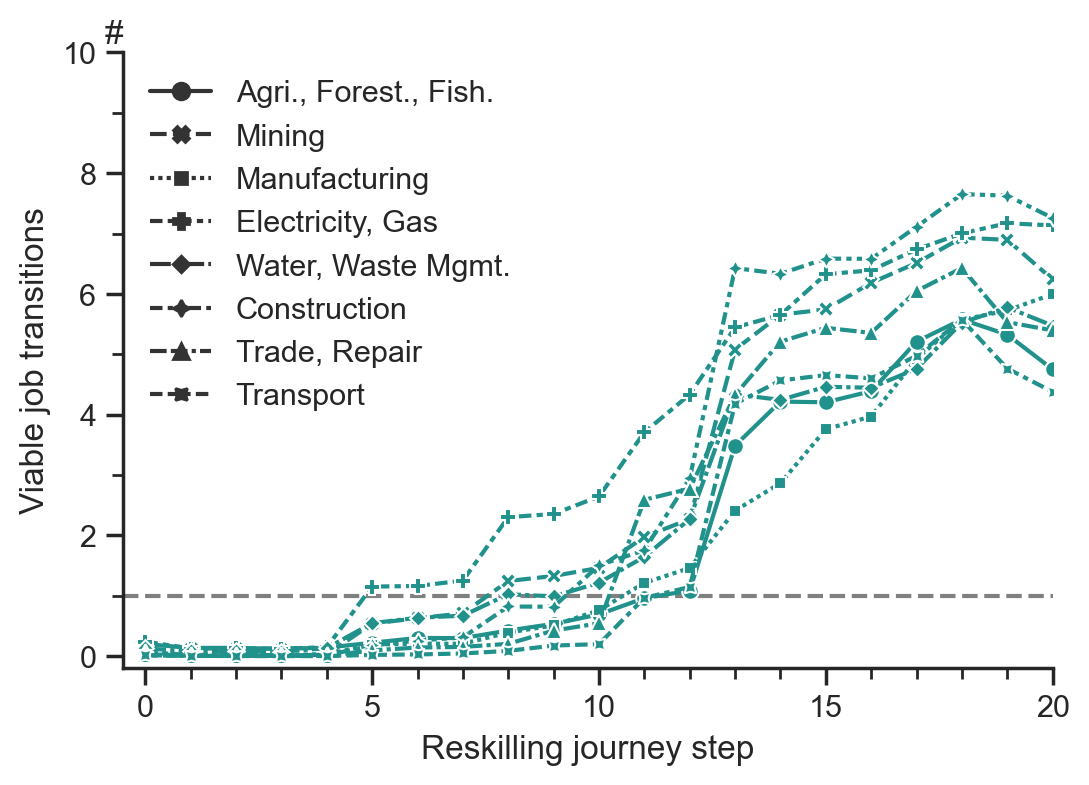

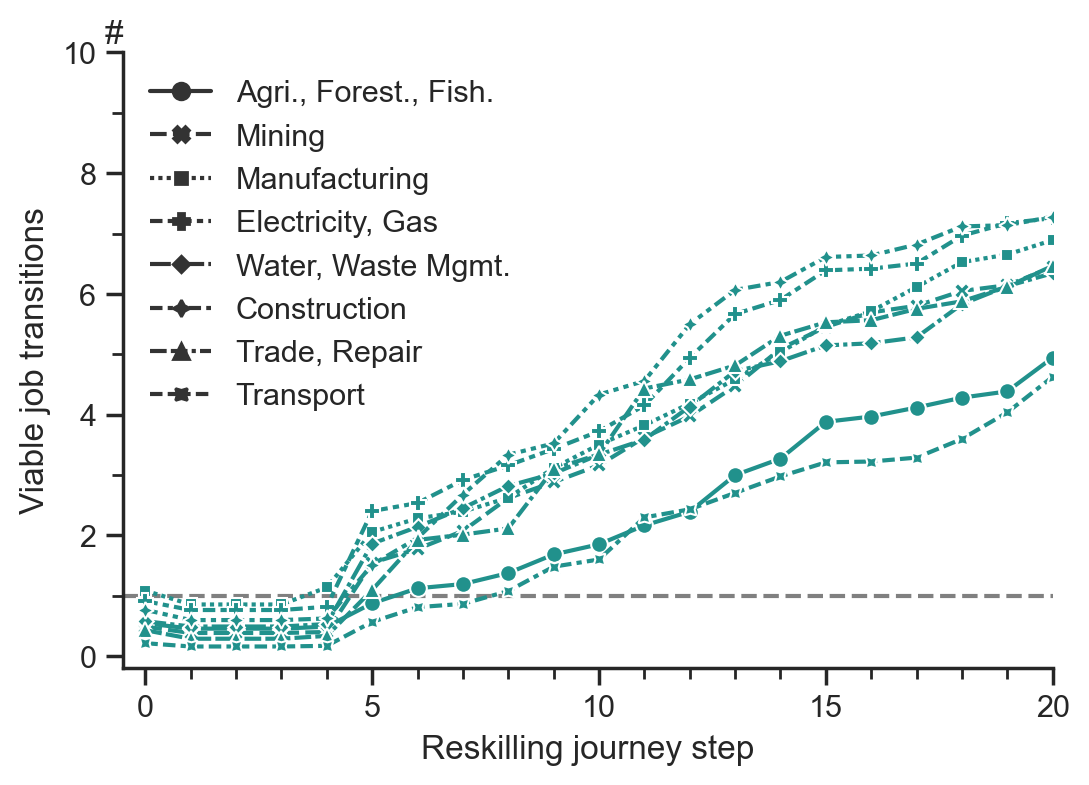

In [25]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
order = reskilling_steps
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_transitions.loc[(data_transitions["regional_constraint"] == reg_constraint) & (data_transitions[hue].isin(hue_order))],
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        palette=palette,
        seed=seed,
        ax=ax,
        legend="brief"
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-0.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Sectors, Main

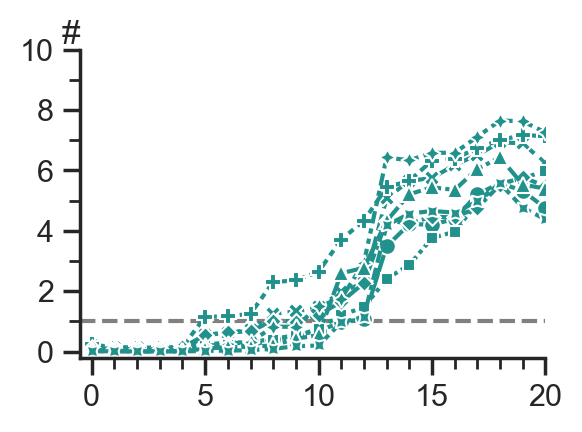

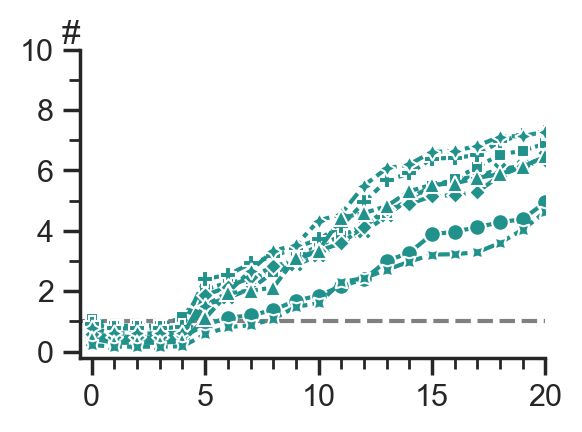

In [26]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_transitions.loc[(data_transitions["regional_constraint"] == reg_constraint) & (data_transitions[hue].isin(hue_order))],
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        palette=palette,
        seed=seed,
        ax=ax,
        legend=False
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left")

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Countries, Appendix

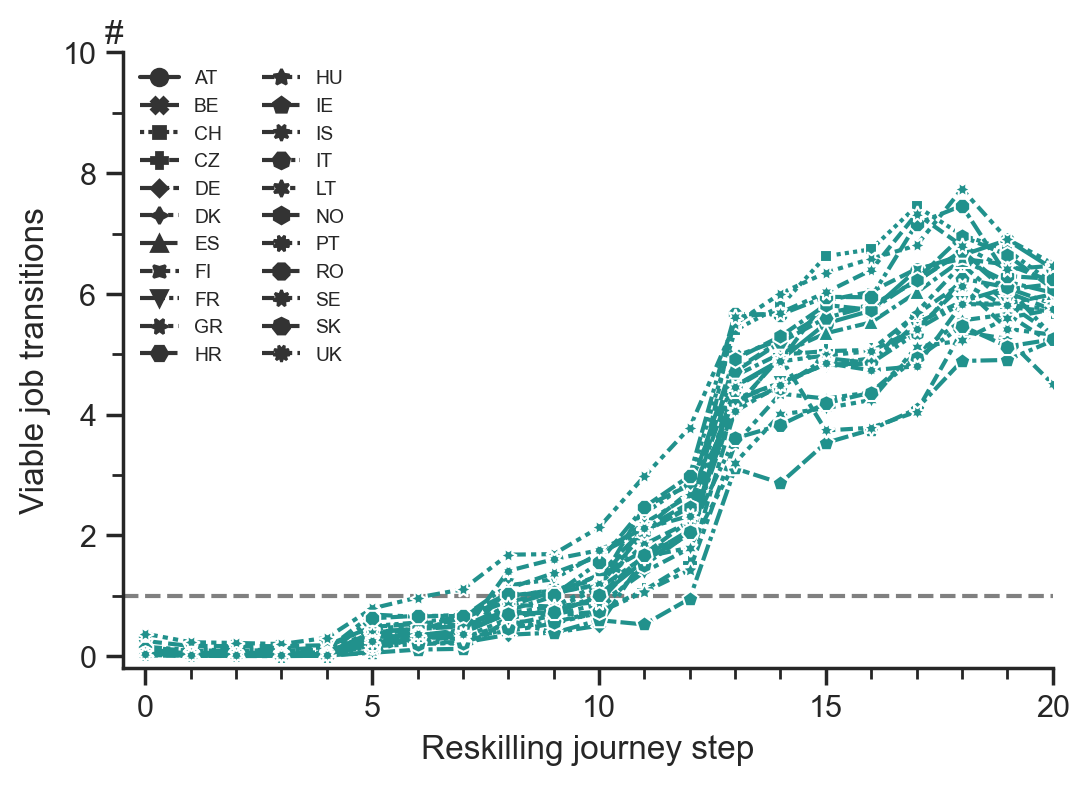

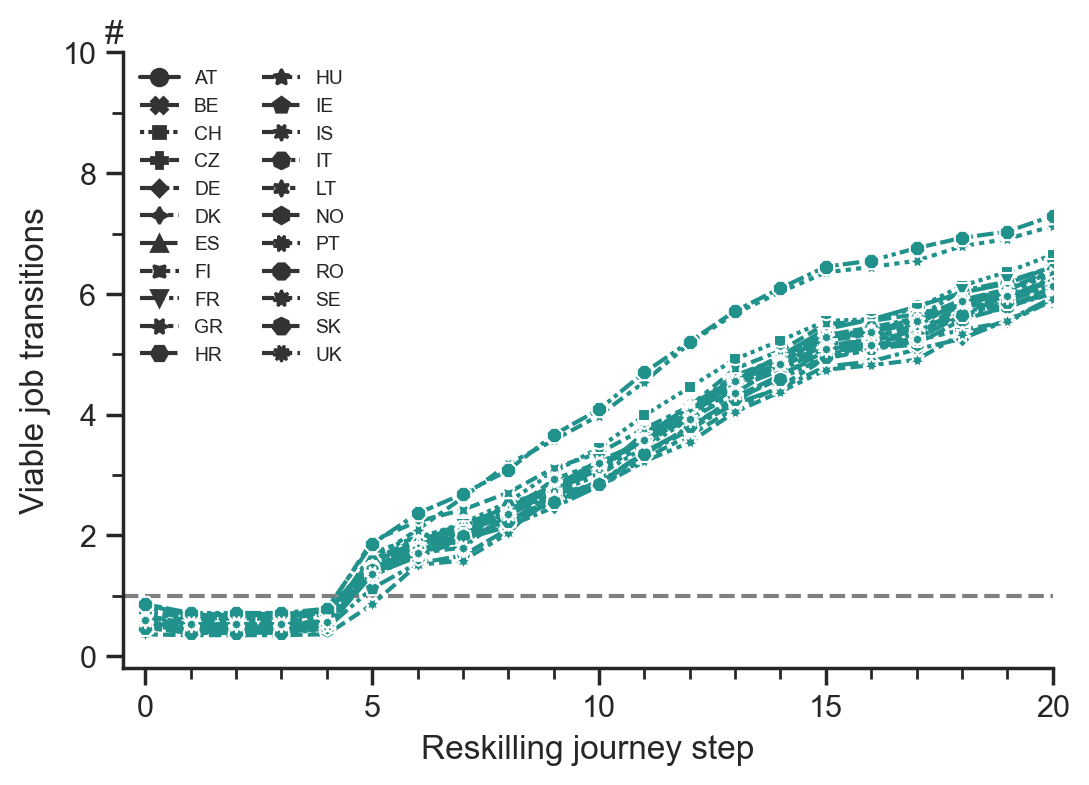

In [27]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
order = reskilling_steps
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_transitions.loc[(data_transitions["regional_constraint"] == reg_constraint) & (data_transitions[hue].isin(hue_order))],
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        palette=palette,
        seed=seed,
        ax=ax,
        legend="brief"
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left", ncol=2, fontsize="xx-small")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Countries, Main

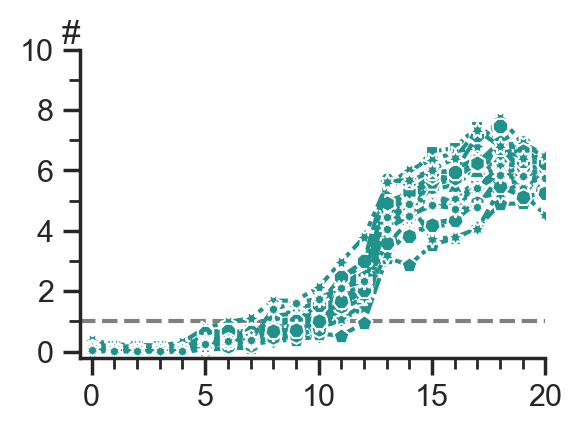

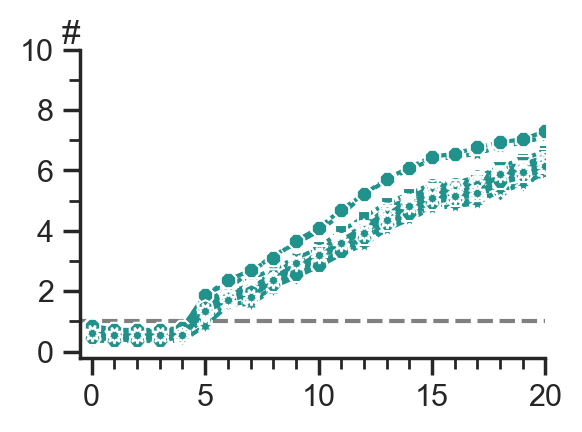

In [28]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_transitions.loc[(data_transitions["regional_constraint"] == reg_constraint) & (data_transitions[hue].isin(hue_order))],
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        palette=palette,
        seed=seed,
        ax=ax,
        legend=False
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Main

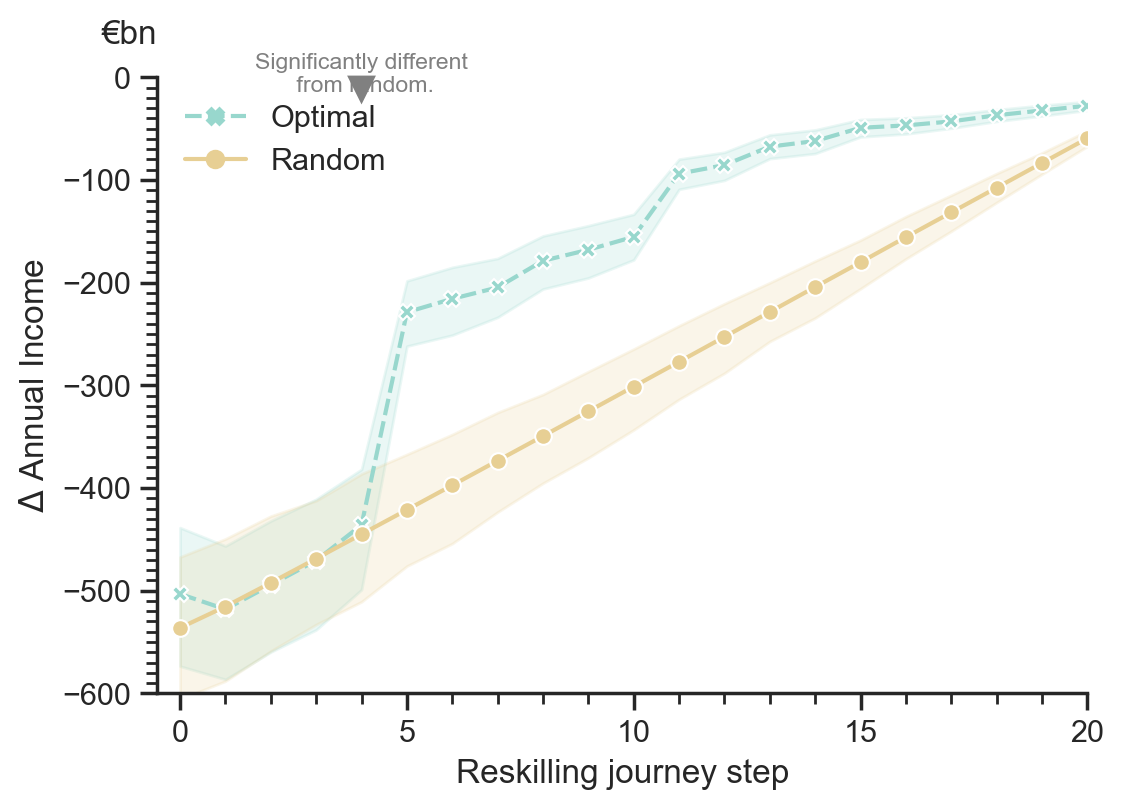

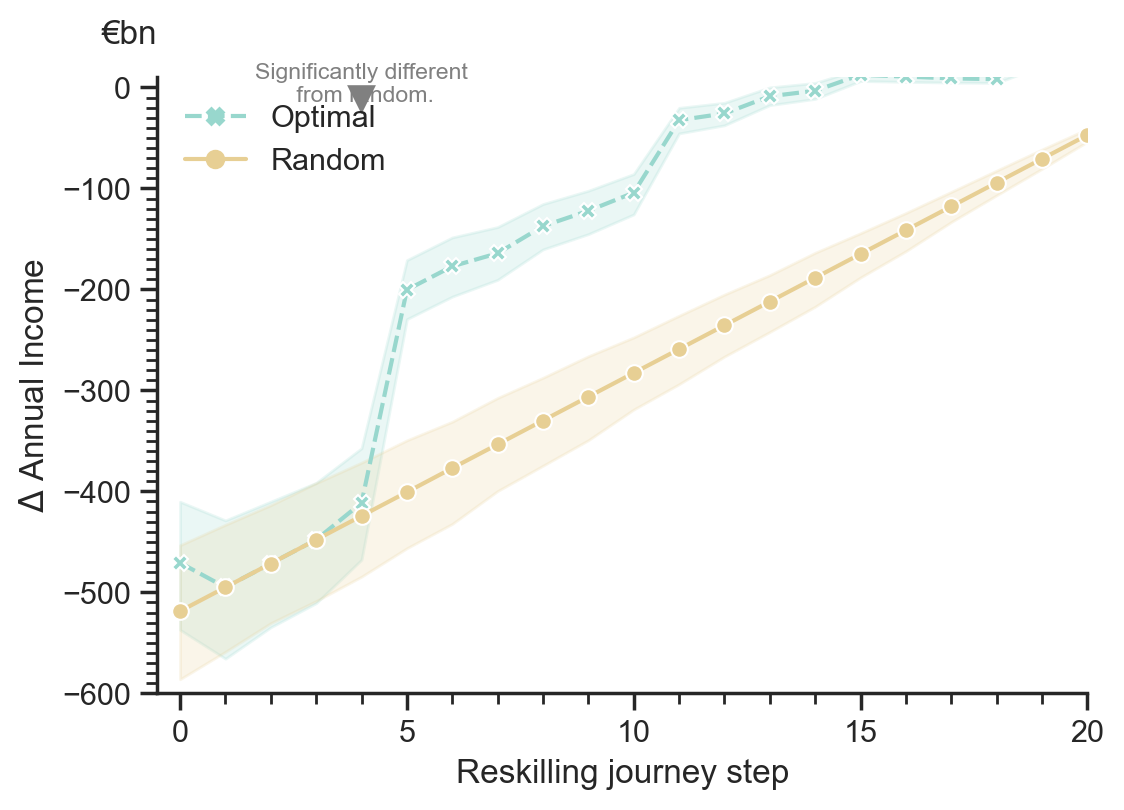

In [39]:
x = "reskilling_step"
y = "earnings_delta_abs_bio"
hue = "reskilling_mode"
style = hue
hue_order = [
    "reskill-optimal",
    "reskill-random",
]
palette = "BrBG_r"

for reg_constraint in regional_constraints:
    # lineplot
    figsize=(6, 4)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_earnings.loc[data_earnings["regional_constraint"] == reg_constraint],
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order,
        estimator=np.sum,
        markers=True,
        palette=palette,
    )

    # annotation
    x_sign, y_sign = 4, -30000 / 10**3
    text = "Significantly different\n from random.".format(x_sign)
    ax.annotate(
        text, xy=(x_sign, y_sign),
        xytext=(x_sign, y_sign+12000 / 10**3),
        fontsize="x-small",
        arrowprops=dict(facecolor='grey', shrink=0.05, width=3), color="grey",
        horizontalalignment='center', verticalalignment='bottom',
    )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings_bio, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, legends = ax.get_legend_handles_labels()
    legend_locs = [0, 1]
    handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    labels_new = ["Optimal", "Random"]
    ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False)

    # axes limits and ticks
    xmax = 20
    ymin = -600000 / 10**3
    ymax = 0 if reg_constraint == "regC" else 10000
    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(ymin, ymax / 10**3)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    # ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
    ax.set_yticks(np.arange(ymin, ymax / 10**3, 10000 / 10**3), minor=True)

    # styling
    #ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel_earnings)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Main, Relative

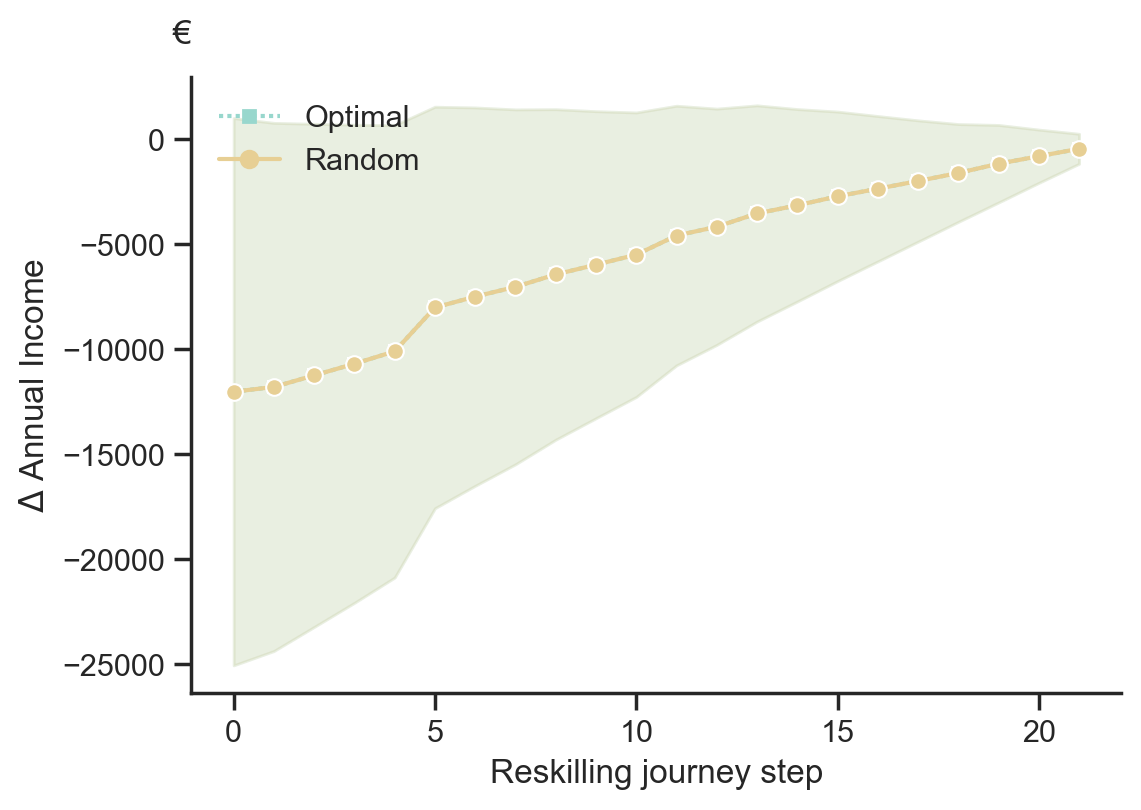

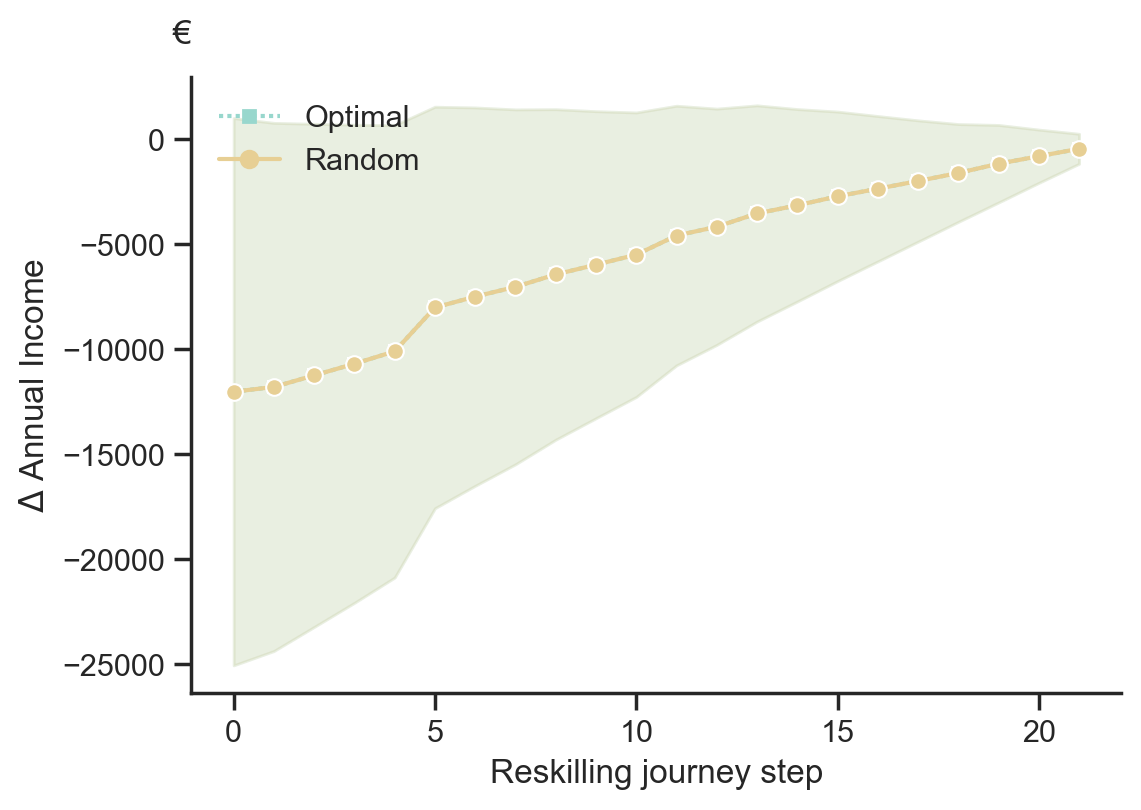

In [30]:
x = "reskilling_step"
y = "earnings_delta_rel"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = hue
hue_order = [
    # "baseline",
    "reskill-optimal",
    "reskill-random",
    # "reskill-coreWeight",
    # "reskill-digital",
]
palette = "BrBG_r"

for reg_constraint in regional_constraints:
    # lineplot
    figsize=(6, 4)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=df_tidy_long_earnings_merged.loc[df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint],
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order,
        estimator=estimator,
        errorbar=errorbar,
        markers=True,
        palette=palette,
    )

    # # annotation
    # x_sign, y_sign = 4, -30000 / 10**3
    # text = "Significantly different from\n null model with +{} skills.".format(x_sign)
    # ax.annotate(
    #     text, xy=(x_sign, y_sign),
    #     xytext=(x_sign, y_sign+10000 / 10**3),
    #     arrowprops=dict(facecolor='grey', shrink=0.01), color="grey",
    #     horizontalalignment='center', verticalalignment='bottom',
    # )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, legends = ax.get_legend_handles_labels()
    legend_locs = [0, 1]
    handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    labels_new = ["Optimal", "Random"]
    ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False)

    # # axes limits and ticks
    # xmax = 20
    # ymin = -100000 / 10**3
    #
    # ax.set_xlim(-0.5, xmax)
    # ax.set_ylim(ymin, 10000 / 10**3)
    #
    # ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    # ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    # ax.set_yticks(np.arange(ymin, 10001 / 10**3, 10000 / 10**3), minor=True)

    # styling
    #ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel_earnings)
    sns.despine()

    # save
    # plt.savefig(
    #     os.path.join(
    #         results_dir,
    #         "{}_{}_by_{}_and_{}_{}.png".format(job_pool, y, hue, style, reg_constraint),
    #     ),
    #     bbox_inches="tight",
    #     dpi=300,
    # )

##### Fig 5b: Earnings changes across reskilling journey, Sectors, Appendix

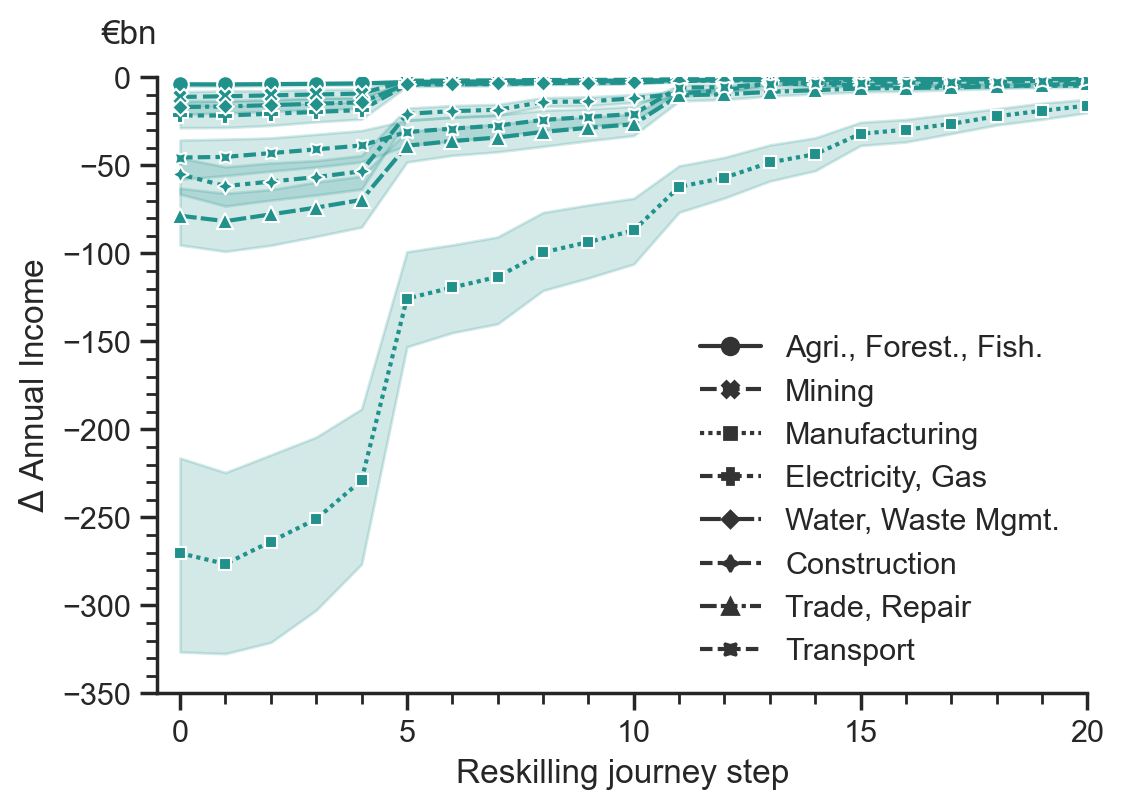

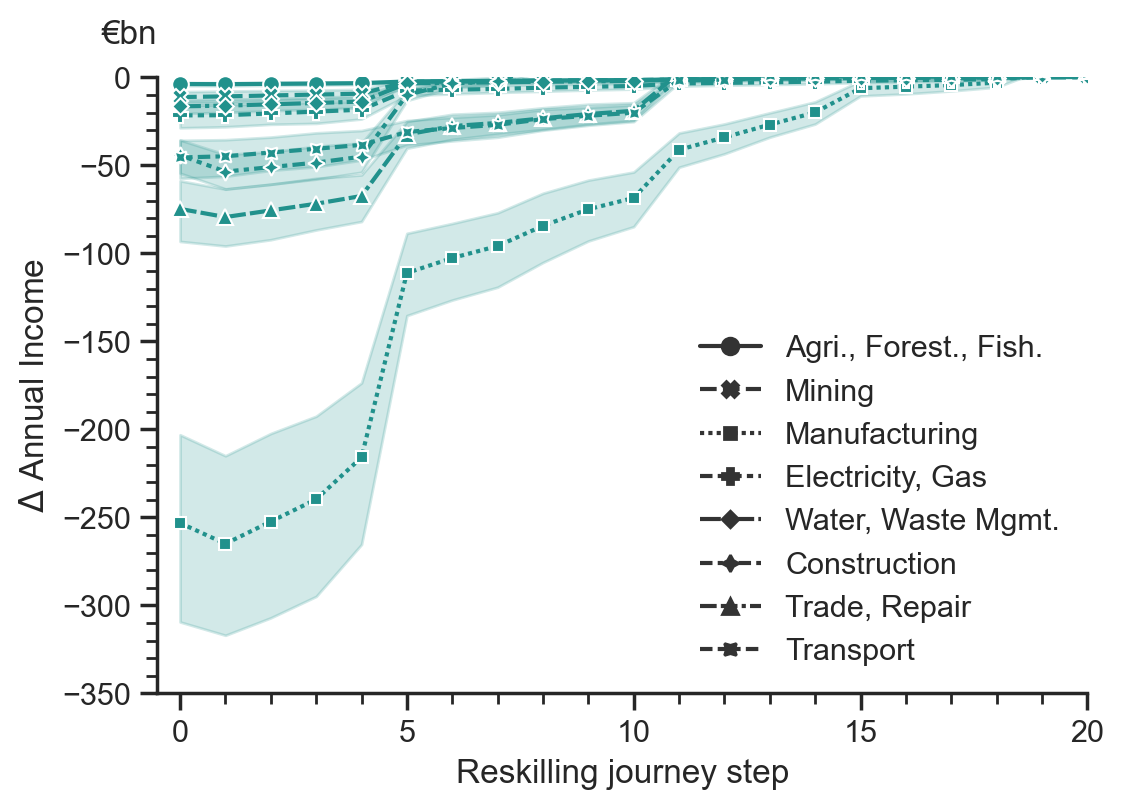

In [42]:
x = "reskilling_step"
y = "earnings_delta_abs_bio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_earnings.loc[(data_earnings[hue].isin(hue_order)) & (data_earnings["regional_constraint"] == reg_constraint)],
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order,
        estimator=np.sum,
        markers=True,
        palette=palette,
        ax=ax
    )

    # axes limits and ticks
    xmax = 20
    ymin = -350000 / 10**3

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(ymin, 0 / 10**3)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    # ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
    ax.set_yticks(np.arange(ymin, 0 / 10**3, 10000 / 10**3), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_earnings_bio, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="lower right")

    # styling
    # ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(ylabel_earnings)
    ax.set_xlabel(xlabel)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Sectors, Main

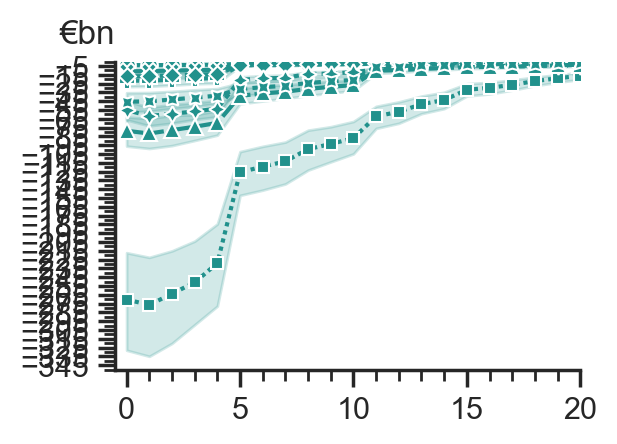

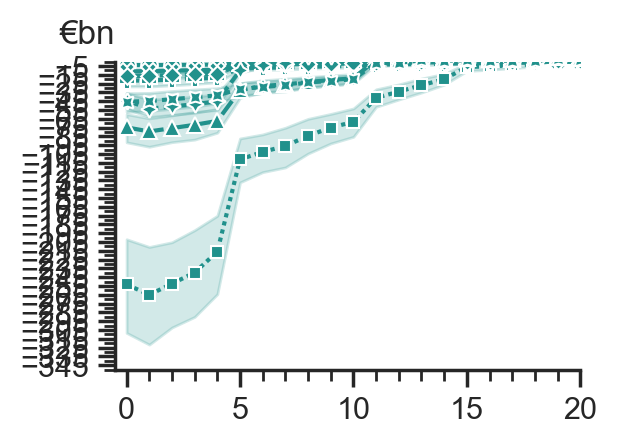

In [43]:
x = "reskilling_step"
y = "earnings_delta_abs_bio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_earnings.loc[(data_earnings[hue].isin(hue_order)) & (data_earnings["regional_constraint"] == reg_constraint)],
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order,
        estimator=np.sum,
        markers=True,
        palette=palette,
        ax=ax,
        legend=False
    )

    # axes limits and ticks
    xmin = -.5
    xmax = 20
    ymin = -350000 / 10**3
    ymax = 1 / 10**3

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax / 10**3)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(ymin, ymax, 10000 / 10**3), minor=True)
    ax.set_yticks(np.arange(ymin + 5000 / 10**3, ymax, 10000 / 10**3), major=True)

    # annotate units to y-axis
    ax.annotate(yax_title_earnings_bio, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    #ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Countries, Appendix

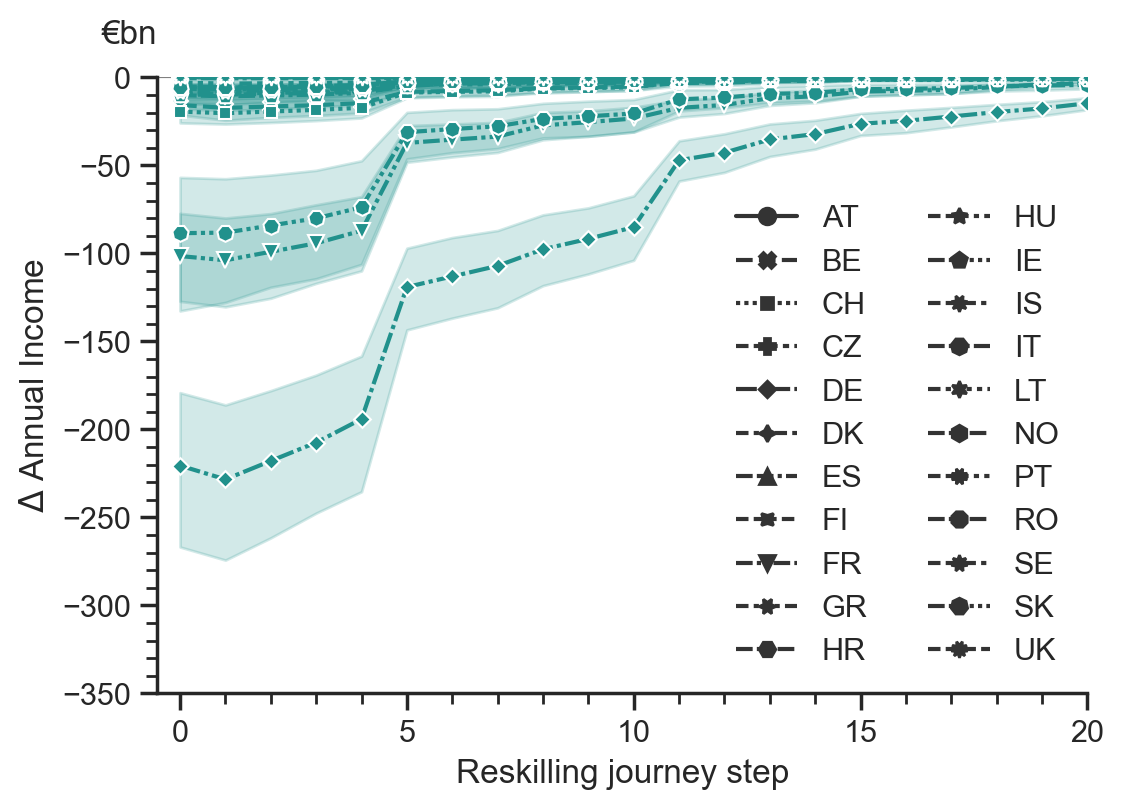

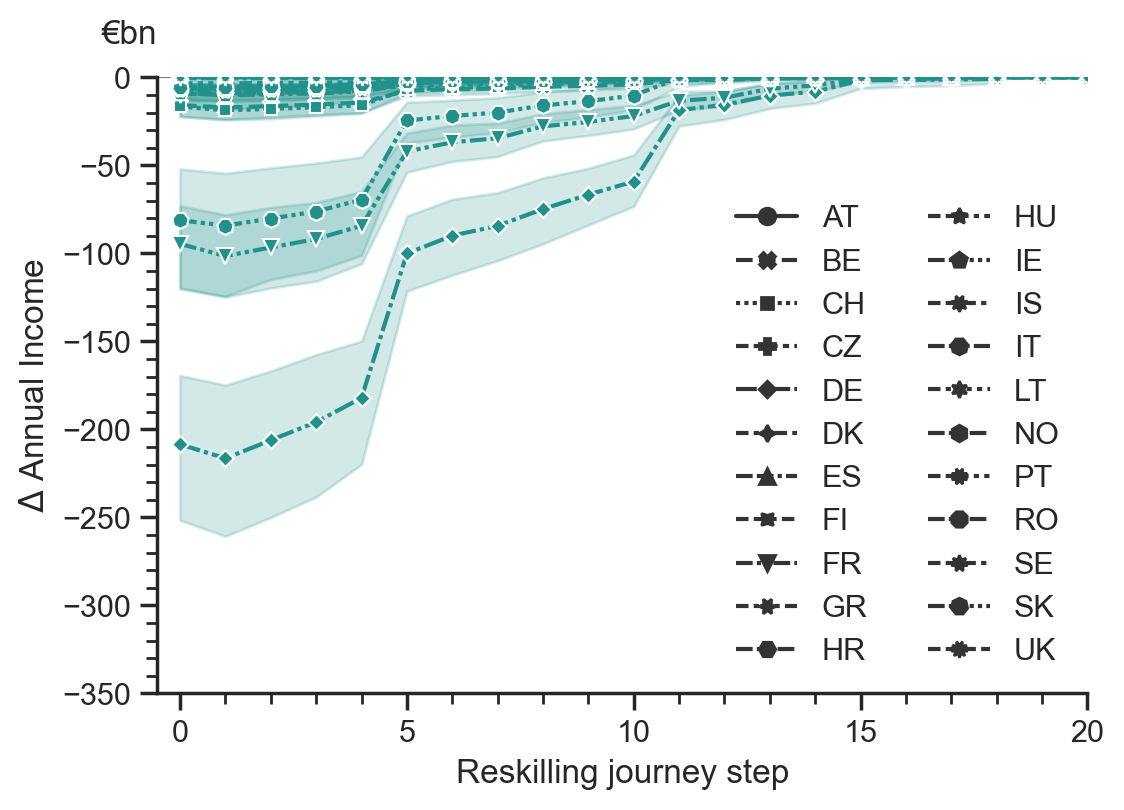

In [44]:
x = "reskilling_step"
y = "earnings_delta_abs_bio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_earnings.loc[(data_earnings[hue].isin(hue_order)) & (data_earnings["regional_constraint"] == reg_constraint)],
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order,
        estimator=np.sum,
        markers=True,
        palette=palette,
        ax=ax
    )

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="lower right", ncol=2)

    # axes limits and ticks
    xmax = 20
    ymin = -350000 / 10**3

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(ymin, 0 / 10**3)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    # ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
    ax.set_yticks(np.arange(ymin, 0, 10000 / 10**3), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_earnings_bio, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(ylabel_earnings)
    ax.set_xlabel(xlabel)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Countries, Main

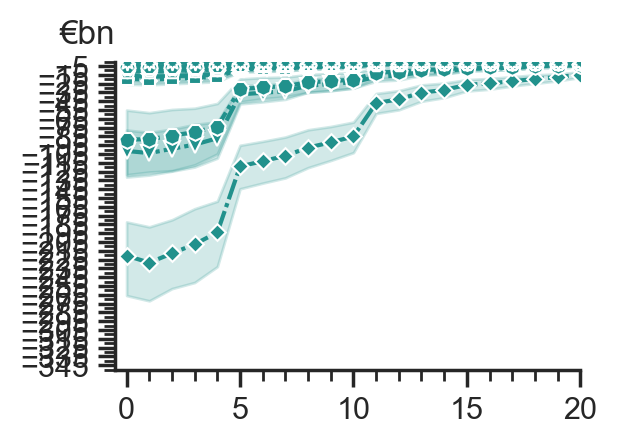

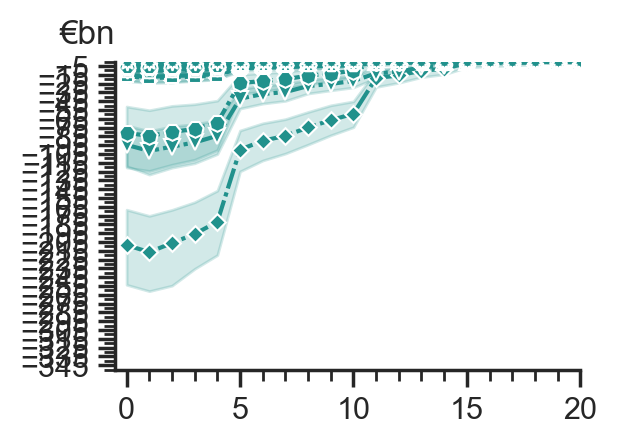

In [45]:
x = "reskilling_step"
y = "earnings_delta_abs_bio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:
    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data_earnings.loc[(data_earnings[hue].isin(hue_order)) & (data_earnings["regional_constraint"] == reg_constraint)],
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order,
        estimator=np.sum,
        markers=True,
        palette=palette,
        ax=ax,
        legend=False
    )

    # axes limits and ticks
    xmin = -.5
    xmax = 20
    ymin = -350000 / 10**3
    ymax = 1 / 10**3

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax / 10**3)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(ymin, ymax, 10000 / 10**3), minor=True)
    ax.set_yticks(np.arange(ymin + 5000 / 10**3, ymax, 10000 / 10**3), major=True)

    # annotate units to y-axis
    ax.annotate(yax_title_earnings_bio, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    #ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    sns.despine()

    # save
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [ ]:
assert 1 == 2

#### Transition numbers

##### Regional

Boxplot

In [ ]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    "reskill-optimal",
]
order = ["no-regC", "regC"]
sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df_tidy,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # country-level stripplot
    sns.stripplot(
        x=x,
        y=y,
        data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]],
        order=order,
        hue_order=hue_order,
        hue=hue,
        dodge=True,
        marker="o",
        size=4,
        edgecolor="black",
        palette=palette,
        alpha=0.5,
        ax=ax,
    )
    ax.legend([], [], frameon=False)

    # # country-level scatterplot
    # sns.scatterplot(
    #     x=hue,
    #     y=y,
    #     data_transitions=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]].dropna(subset=["COUNTRYW"]),
    #     style="COUNTRYW",
    #     hue="COUNTRYW",
    #     marker='o',
    #     size=4,
    #     edgecolor="black",
    #     palette="Paired",
    #     alpha=0.5,
    #     ax=ax,
    # )

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax,
        pairs,
        data=df_tidy,
        x=x,
        y=y,
        order=order,
        hue=hue,
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "test"
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
df_final_by_country.query(
    "(job_pool=='CPO') & (reskilling_mode=='baseline') & (regional_constraint=='no-regC')"
)

In [ ]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    ci="sd",
    height=5,
    aspect=1,
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:

    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

In [ ]:
x = "reskilling_mode"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
# order = ["no-regC", "regC"]
sharey = True

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    # order=order,
    kind="box",
    sharey=sharey,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs_regional_hue, data=df_regions, x=x, y=y, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

##### Sectors

In [ ]:
sectors = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]

pairs_sectors = []
for sector in sectors:
    # with regional constraints
    pair = ((sector, "baseline"), (sector, "reskill-optimal"))
    pairs_sectors.append(pair)

In [ ]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order = [
    "baseline",
    "reskill-optimal",
]

sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Job transition options (-)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
axes

#### Income changes

John Tukey, who was a driving force in the development of exploratory data analysis, defined outliers as points more than 1.5 x IQR. Recall that IQR is the inter-quartile range, which captures 50% of the data points in a data set.

[https://neuraldatascience.io/5-eda/data_cleaning.html]()


##### Regions

Hue = reskilling mode

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1,
    ci=None,
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=True,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_sum.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    height=5,
    aspect=1,
    ci="sd",
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_mean.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "box"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    height=5,
    aspect=1,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Sectors

In [ ]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "earnings_delta_closest_switch_sum_mio"  # n_viable_transitions / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order = [
    "baseline",
    "reskill-optimal",
]

sharey = True
sharex = False
kind = "bar"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci="sd",
    # flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_income_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

#### Results by country

In [ ]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "box"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for ax in axes:
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "bar"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    ci="sd",
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=7,
    aspect=1,
    palette=palette,
)

aggdict = {
    "n_viable_transitions": [np.mean, np.std],
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}
df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot.columns = ["_".join(col) for col in df_annot.columns]
df_annot = df_annot.reindex(order, level=1).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        labels = (
            df_hue.loc[:, "n_viable_transitions_mean"].round(1).astype(str)
            + r" $\pm$ "
            + df_hue.loc[:, "n_viable_transitions_std"].round(1).astype(str)
        )
        ax.bar_label(container, labels=labels, fontsize=8, label_type="center")

        # annotate mean
        x = df_hue["n_viable_transitions_mean"].mean()
        c = container[-1].get_facecolor()
        ax.axvline(x, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            x,
            0,
            "$\mu = {:.1f}$".format(x),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
ax.containers[0][-1].get_facecolor()

In [ ]:
df_hue

In [ ]:
df_annot

In [ ]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "box"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "bar"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

# calc order
df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci=False,
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot = df_annot.reindex(order, level=0).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")
    ax.grid(linestyle=":", axis="x")

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        ax.bar_label(
            container, labels=df_hue[x], fmt="%.0f", fontsize=8, label_type="edge"
        )
        # annotate mean
        pos = np.nanmean(df_hue["earnings_delta_closest_switch_sum_mio"])
        c = container[-1].get_facecolor()
        ax.axvline(pos, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            pos,
            0,
            r"$\mu = {:.1f}$".format(pos),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
df_hue